# Indian Options Dashboard — Full Analysis
**Assets:** NIFTY · BANKNIFTY · FINNIFTY · MIDCPNIFTY · SENSEX · BANKEX

**Model-specific pipelines:**
| Model Family | Pipeline | Input | Preprocessing |
|---|---|---|---|
| GARCH / EGARCH / GJR-GARCH | `GarchPipeline` | Spot log-returns | ADF + Ljung-Box EDA |
| SARIMA | `SarimaPipeline` | Spot log-returns | ADF + ACF/PACF EDA |
| CatBoost / XGBoost / LightGBM | `TreePipeline` | Tabular option features | 3σ clip, no scaling |
| LSTM / Transformer | `DeepPipeline` | Per-symbol sequences | StandardScaler (train only) |

---
**Sections:**
1. Setup & Data Summary
2. Index Price History & Returns
3. GARCH/SARIMA EDA — Stationarity, ARCH Effects, Order Selection
4. Volatility Forecasts — All Models, All Assets
5. Option Chain Snapshot — Greeks, IV Surface, PCR
6. Tree Model EDA — Feature Correlations, Outliers, Moneyness
7. Deep Model EDA — Sequence Lengths, Temporal Gaps
8. Model Performance — AUC, Feature Importance
9. Live Signal Scoring
10. Historical Greeks Over Time
11. Multi-Asset Normalised Returns

In [2]:
import os, sys, sqlite3, warnings, importlib
os.environ.setdefault('OMP_NUM_THREADS', '1')
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from dotenv import load_dotenv

load_dotenv()
DB_PATH    = os.getenv('DB_PATH', 'data.db')
MODELS_DIR = os.getenv('MODELS_DIR', 'trained_models')

ASSETS  = ['NIFTY','BANKNIFTY','FINNIFTY','MIDCPNIFTY','SENSEX','BANKEX']
COLORS  = {'NIFTY':'#111','BANKNIFTY':'#c0392b','FINNIFTY':'#1a7a3c',
           'MIDCPNIFTY':'#2471a3','SENSEX':'#7d3c98','BANKEX':'#d35400'}

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white',
    'axes.edgecolor':'#333','axes.grid':True,'grid.color':'#ebebeb',
    'grid.linewidth':0.6,'font.size':10,
    'axes.spines.top':False,'axes.spines.right':False,
})

def qdf(sql, params=()):
    with sqlite3.connect(DB_PATH) as c:
        return pd.read_sql_query(sql, c, params=params)

print('DB:', DB_PATH)
for t in ['historical_candle','historical_option','option_chain_snapshot']:
    n = qdf(f'SELECT COUNT(*) as n FROM {t}').iloc[0]['n']
    print(f'  {t}: {n:,} rows')

DB: data.db
  historical_candle: 372 rows
  historical_option: 5,602 rows
  option_chain_snapshot: 198,180 rows


## 1. Index Price History & Returns

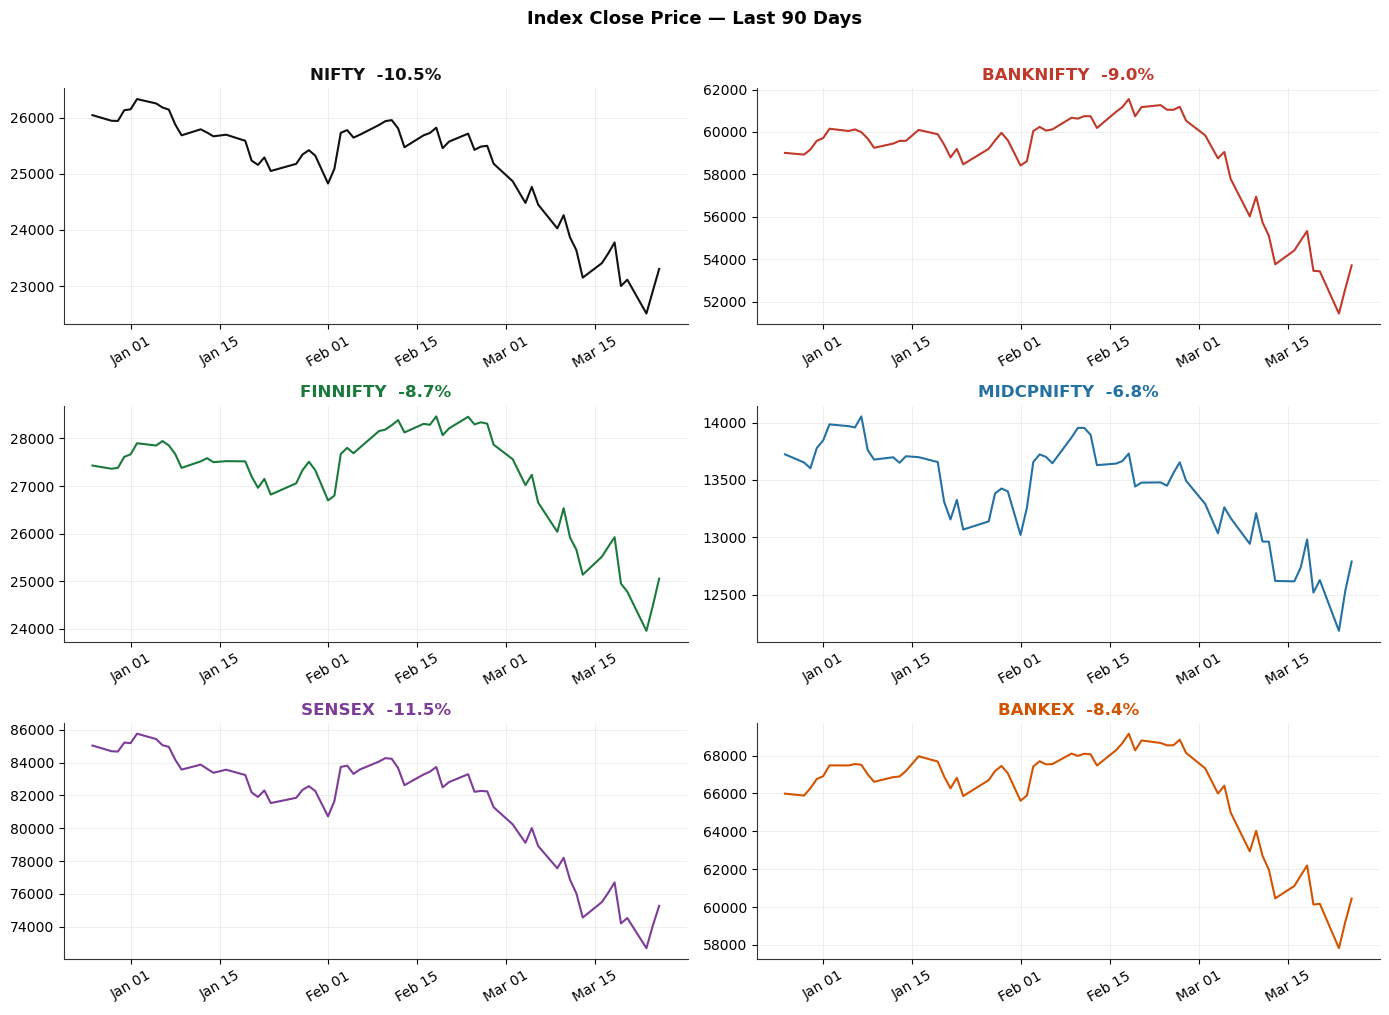

In [3]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Index Close Price — Last 90 Days', fontsize=13, fontweight='bold', y=1.01)

for ax, asset in zip(axes.flat, ASSETS):
    exc = 'BSE' if asset in ('SENSEX','BANKEX') else 'NSE'
    df = qdf("SELECT ts, close FROM historical_candle WHERE symbol=? AND exchange=? AND interval='1d' ORDER BY ts",
             (asset, exc))
    if df.empty:
        ax.set_title(f'{asset} — no data', fontweight='bold'); continue
    df['ts'] = pd.to_datetime(df['ts'], unit='ns')
    start, end = df['close'].iloc[0], df['close'].iloc[-1]
    ret = (end - start) / start * 100
    ax.plot(df['ts'], df['close'], color=COLORS[asset], linewidth=1.5)
    ax.set_title(f"{asset}  {ret:+.1f}%", fontweight='bold', color=COLORS[asset])
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()

In [4]:
# Returns summary table
rows = []
for asset in ASSETS:
    exc = 'BSE' if asset in ('SENSEX','BANKEX') else 'NSE'
    df = qdf("SELECT ts, close FROM historical_candle WHERE symbol=? AND exchange=? AND interval='1d' ORDER BY ts",
             (asset, exc))
    if len(df) < 5: continue
    df['ts'] = pd.to_datetime(df['ts'], unit='ns')
    prices = df.set_index('ts')['close']
    log_ret = np.log(prices / prices.shift(1)).dropna() * 100
    roll_max = prices.cummax()
    dd = (prices - roll_max) / roll_max * 100
    rows.append({
        'Asset': asset,
        'Start': f"{prices.iloc[0]:,.0f}",
        'End':   f"{prices.iloc[-1]:,.0f}",
        'Return': f"{(prices.iloc[-1]-prices.iloc[0])/prices.iloc[0]*100:+.1f}%",
        'Ann.Vol': f"{log_ret.std()*np.sqrt(252):.1f}%",
        'MaxDD':   f"{dd.min():.1f}%",
        'MaxDD Date': str(dd.idxmin().date()),
    })
pd.DataFrame(rows).set_index('Asset')

,Start,End,Return,Ann.Vol,MaxDD,MaxDD Date
Asset,,,,,,
NIFTY,"26,042","23,306",-10.5%,17.4%,-14.5%,2026-03-23
BANKNIFTY,"59,011","53,708",-9.0%,20.3%,-16.4%,2026-03-23
FINNIFTY,"27,431","25,056",-8.7%,21.0%,-15.8%,2026-03-23
MIDCPNIFTY,"13,723","12,788",-6.8%,23.5%,-13.3%,2026-03-23
SENSEX,"85,041","75,273",-11.5%,17.1%,-15.2%,2026-03-23
BANKEX,"65,991","60,449",-8.4%,20.9%,-16.4%,2026-03-23


## 2. GARCH / SARIMA EDA — Stationarity, ARCH Effects, Order Selection

**GarchPipeline** runs before fitting any vol model:
- ADF test confirms returns are stationary (required for GARCH)
- Ljung-Box test on squared returns confirms ARCH effects exist
- Auto-selects best GARCH(p,q) order by AIC

**SarimaPipeline** runs before SARIMA:
- ADF on log prices (non-stationary → d=1 needed)
- ADF on returns (stationary → d=0 in ARIMA)
- ACF/PACF significant lags guide p, q selection

In [5]:
import models.data_pipeline as _dp; importlib.reload(_dp)
from models.data_pipeline import GarchPipeline, SarimaPipeline

eda_rows = []
for asset in ASSETS:
    gp = GarchPipeline(DB_PATH, asset)
    g  = gp.run_eda()
    sp = SarimaPipeline(DB_PATH, asset)
    s  = sp.run_eda()
    if 'error' in g: continue
    eda_rows.append({
        'Asset':       asset,
        'n':           g['n'],
        'Mean Ret%':   g['mean'],
        'Std%':        g['std'],
        'Skew':        g['skew'],
        'Kurt':        g['kurtosis'],
        'ADF p':       g['adf_pvalue'],
        'Stationary':  '✓' if g['stationary'] else '✗',
        'ARCH':        '✓' if g['arch_effects'] else '✗',
        'Best GARCH':  f"GARCH{g['best_garch_order']}",
        'GARCH AIC':   g['best_garch_aic'],
        'SARIMA d':    s.get('suggested_d','?'),
        'Sig PACF':    str(s.get('sig_pacf_lags',[])),
    })

df_eda = pd.DataFrame(eda_rows).set_index('Asset')
print('=== Vol Model EDA Summary ===')
df_eda

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


,n,Mean Ret%,Std%,Skew,Kurt,ADF p,Stationary,ARCH,Best GARCH,GARCH AIC,SARIMA d,Sig PACF
Asset,,,,,,,,,,,,
NIFTY,61,-0.1820,1.0930,-0.3927,0.4513,0.0,✓,✓,"GARCH(1, 1)",178.65,0,[12]
BANKNIFTY,61,-0.1544,1.2793,-0.7565,0.8836,0.0,✓,✓,"GARCH(1, 1)",188.67,0,"[12, 16]"
FINNIFTY,61,-0.1484,1.3233,-0.4062,0.7298,0.0,✓,✓,"GARCH(2, 1)",195.52,0,"[12, 16]"
MIDCPNIFTY,61,-0.1156,1.4787,-0.3511,-0.0434,0.0,✓,✗,"GARCH(1, 1)",222.32,0,"[12, 16]"
SENSEX,61,-0.2000,1.0791,-0.3001,0.4523,0.0,✓,✓,"GARCH(1, 1)",175.50,0,[12]
BANKEX,61,-0.1438,1.3150,-0.7876,0.7974,0.0,✓,✓,"GARCH(1, 1)",194.52,0,"[12, 16]"


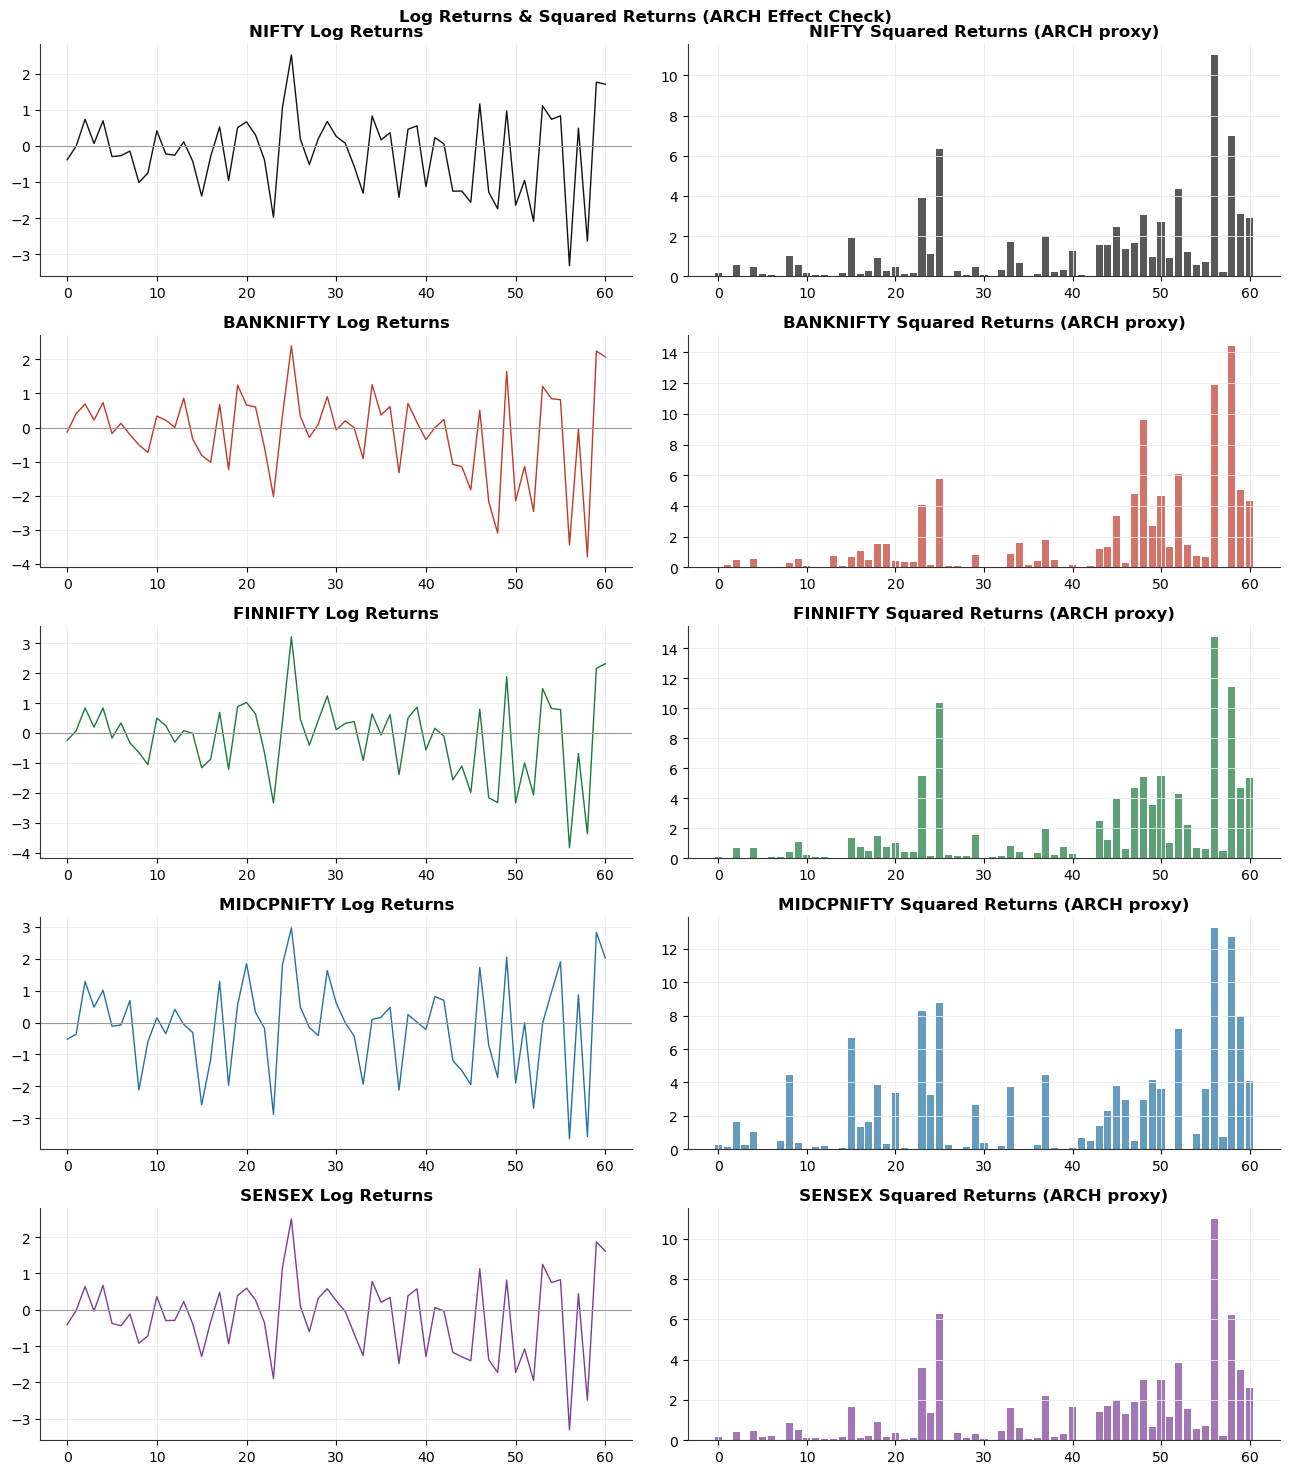

In [6]:
# Visualise returns + squared returns for ARCH effect check
fig, axes = plt.subplots(len([a for a in ASSETS if a not in ('BANKEX',)]), 2,
                         figsize=(13, 3*5))
fig.suptitle('Log Returns & Squared Returns (ARCH Effect Check)', fontsize=12, fontweight='bold')

row = 0
for asset in ASSETS:
    if asset == 'BANKEX': continue
    exc = 'BSE' if asset in ('SENSEX',) else 'NSE'
    df = qdf("SELECT close FROM historical_candle WHERE symbol=? AND exchange=? AND interval='1d' ORDER BY ts",
             (asset, exc))
    if len(df) < 10: continue
    ret = np.log(df['close'] / df['close'].shift(1)).dropna() * 100
    axes[row,0].plot(ret.values, color=COLORS[asset], lw=1)
    axes[row,0].set_title(f'{asset} Log Returns', fontweight='bold')
    axes[row,0].axhline(0, color='#999', lw=0.8)
    axes[row,1].bar(range(len(ret)), ret.values**2, color=COLORS[asset], alpha=0.7)
    axes[row,1].set_title(f'{asset} Squared Returns (ARCH proxy)', fontweight='bold')
    row += 1

plt.tight_layout(); plt.show()

## 3. Volatility Forecasts — All Models, All Assets

Each model uses its own EDA-validated pipeline:
- **GARCH(1,1)**: symmetric vol clustering
- **EGARCH(1,1)**: asymmetric leverage effect (analytic h=1, simulation h>1)
- **GJR-GARCH**: negative shocks increase vol more than positive
- **SARIMA**: captures autocorrelation in returns (d=0, weekly seasonality m=5)

In [7]:
import models.vol_models as _vm; importlib.reload(_vm)
from models.vol_models import fit_garch, fit_egarch, fit_gjr_garch, fit_sarima, realized_vol, vol_ensemble

vol_rows = []
for asset in ASSETS:
    exc = 'BSE' if asset in ('SENSEX','BANKEX') else 'NSE'
    df = qdf("SELECT close FROM historical_candle WHERE symbol=? AND exchange=? AND interval='1d' ORDER BY ts",
             (asset, exc))
    if len(df) < 30: continue
    prices = df['close']
    g   = fit_garch(prices)
    e   = fit_egarch(prices)
    gjr = fit_gjr_garch(prices)
    rv  = realized_vol(prices)
    ens = vol_ensemble(prices)
    if 'error' in g: continue
    best = min([('GARCH',g['aic']),('EGARCH',e['aic']),('GJR',gjr['aic'])], key=lambda x:x[1])
    vol_rows.append({
        'Asset':        asset,
        'GARCH 1d%':    g['vol_1d'],
        'EGARCH 1d%':   e['vol_1d'],
        'GJR 1d%':      gjr['vol_1d'],
        'Ensemble 1d%': ens['ensemble_vol_1d'],
        'Realized 20d%':rv,
        'Ann.Vol%':     ens['ensemble_vol_ann'],
        'Best Model':   best[0],
        'Best AIC':     best[1],
    })

df_vol = pd.DataFrame(vol_rows).set_index('Asset')
print('=== Volatility Forecast Summary ===')
df_vol

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


,GARCH 1d%,EGARCH 1d%,GJR 1d%,Ensemble 1d%,Realized 20d%,Ann.Vol%,Best Model,Best AIC
Asset,,,,,,,,
NIFTY,1.9383,1.9197,1.9193,1.9257,23.9988,30.5700,GJR,176.05
BANKNIFTY,2.4137,2.7436,2.5594,2.5725,29.4846,40.8369,GJR,183.58
FINNIFTY,2.4295,2.5807,2.4634,2.4912,29.4563,39.5466,GJR,193.50
MIDCPNIFTY,2.2643,2.2338,2.2216,2.2399,30.8920,35.5570,EGARCH,222.06
SENSEX,1.9602,1.9325,1.8741,1.9221,23.6793,30.5127,GJR,173.56
BANKEX,2.4778,2.6874,2.4876,2.5508,30.1514,40.4920,GJR,191.00


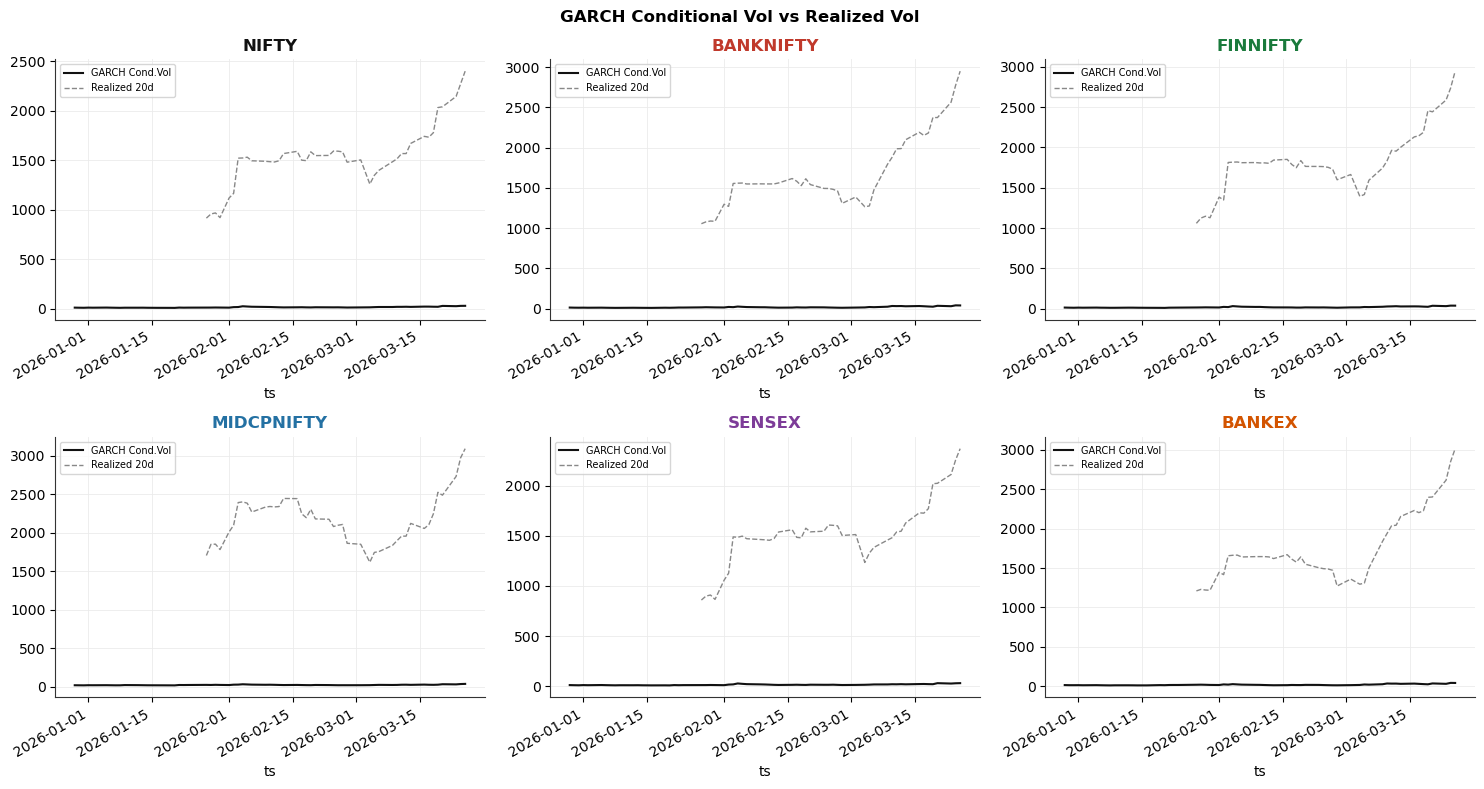

In [8]:
# GARCH conditional vol vs realized vol — NIFTY
from arch import arch_model

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('GARCH Conditional Vol vs Realized Vol', fontsize=12, fontweight='bold')

for ax, asset in zip(axes.flat, ASSETS):
    exc = 'BSE' if asset in ('SENSEX','BANKEX') else 'NSE'
    df = qdf("SELECT ts, close FROM historical_candle WHERE symbol=? AND exchange=? AND interval='1d' ORDER BY ts",
             (asset, exc))
    if len(df) < 30: ax.set_title(f'{asset} — no data'); continue
    df['ts'] = pd.to_datetime(df['ts'], unit='ns')
    prices = df.set_index('ts')['close']
    log_ret = np.log(prices / prices.shift(1)).dropna() * 100
    try:
        res = arch_model(log_ret, vol='Garch', p=1, q=1).fit(disp='off', show_warning=False)
        cond_vol = res.conditional_volatility * np.sqrt(252)
        rv20 = log_ret.rolling(20).std() * np.sqrt(252) * 100
        cond_vol.plot(ax=ax, color='#111', lw=1.5, label='GARCH Cond.Vol')
        rv20.plot(ax=ax, color='#888', lw=1, ls='--', label='Realized 20d')
        ax.set_title(asset, fontweight='bold', color=COLORS[asset])
        ax.legend(fontsize=7)
    except Exception as ex:
        ax.set_title(f'{asset} — {ex}')

plt.tight_layout(); plt.show()

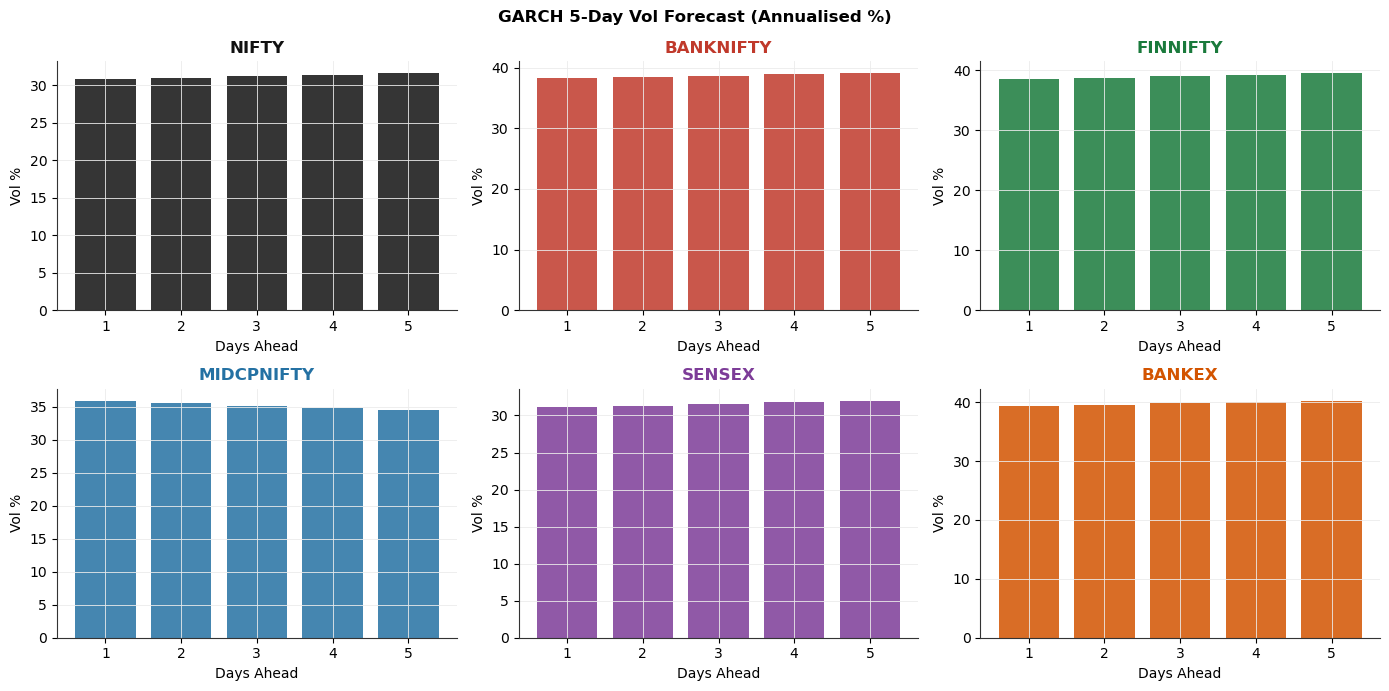

In [9]:
# 5-day GARCH forecast bars — all assets
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('GARCH 5-Day Vol Forecast (Annualised %)', fontsize=12, fontweight='bold')

for ax, asset in zip(axes.flat, ASSETS):
    exc = 'BSE' if asset in ('SENSEX','BANKEX') else 'NSE'
    df = qdf("SELECT close FROM historical_candle WHERE symbol=? AND exchange=? AND interval='1d' ORDER BY ts",
             (asset, exc))
    if len(df) < 30: ax.set_title(f'{asset} — no data'); continue
    log_ret = np.log(df['close'] / df['close'].shift(1)).dropna() * 100
    try:
        res = arch_model(log_ret, vol='Garch', p=1, q=1).fit(disp='off', show_warning=False)
        fc   = res.forecast(horizon=5)
        vols = np.sqrt(fc.variance.values[-1]) * np.sqrt(252)
        ax.bar(range(1,6), vols, color=COLORS[asset], alpha=0.85)
        ax.set_title(asset, fontweight='bold', color=COLORS[asset])
        ax.set_xlabel('Days Ahead'); ax.set_ylabel('Vol %')
    except Exception: pass

plt.tight_layout(); plt.show()

## 4. Option Chain Snapshot — Greeks, IV Surface, PCR

Data from `option_chain_snapshot` table (live snapshots collected during market hours).
CE/PE filtered, `fillna(0)` applied before plotting.

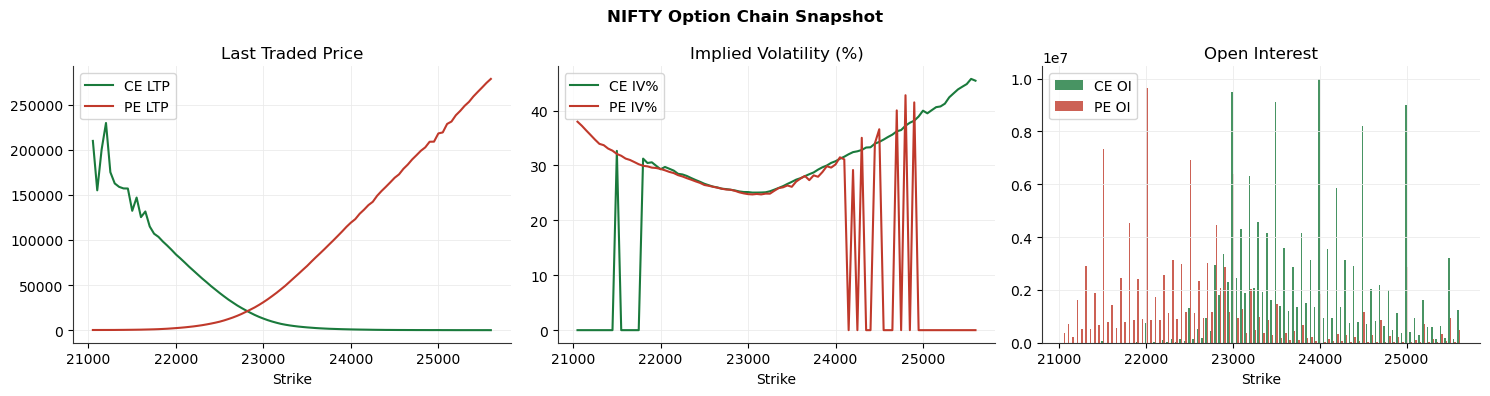

In [10]:
CHAIN_ASSET = 'NIFTY'  # change to BANKNIFTY, FINNIFTY, etc.

df = qdf("""
    SELECT option_type, strike, ltp, iv, delta, gamma, theta, vega, oi, volume
    FROM option_chain_snapshot WHERE asset=?
    ORDER BY collected_at DESC, strike LIMIT 400
""", (CHAIN_ASSET,))

if df.empty:
    print('No snapshot data. Run: python collect_data.py --live 60')
else:
    ce = df[df.option_type=='CE'].drop_duplicates('strike').set_index('strike').fillna(0)
    pe = df[df.option_type=='PE'].drop_duplicates('strike').set_index('strike').fillna(0)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'{CHAIN_ASSET} Option Chain Snapshot', fontsize=12, fontweight='bold')

    axes[0].plot(ce.index/100, ce['ltp'], color='#1a7a3c', label='CE LTP', lw=1.5)
    axes[0].plot(pe.index/100, pe['ltp'], color='#c0392b', label='PE LTP', lw=1.5)
    axes[0].set_title('Last Traded Price'); axes[0].legend()

    axes[1].plot(ce.index/100, ce['iv']*100, color='#1a7a3c', label='CE IV%', lw=1.5)
    axes[1].plot(pe.index/100, pe['iv']*100, color='#c0392b', label='PE IV%', lw=1.5)
    axes[1].set_title('Implied Volatility (%)'); axes[1].legend()

    w = (ce.index[1]-ce.index[0])*0.35 if len(ce)>1 else 50
    axes[2].bar(ce.index/100 - w/200, ce['oi'].fillna(0), width=w/100, color='#1a7a3c', alpha=0.8, label='CE OI')
    axes[2].bar(pe.index/100 + w/200, pe['oi'].fillna(0), width=w/100, color='#c0392b', alpha=0.8, label='PE OI')
    axes[2].set_title('Open Interest'); axes[2].legend()

    for ax in axes: ax.set_xlabel('Strike')
    plt.tight_layout(); plt.show()

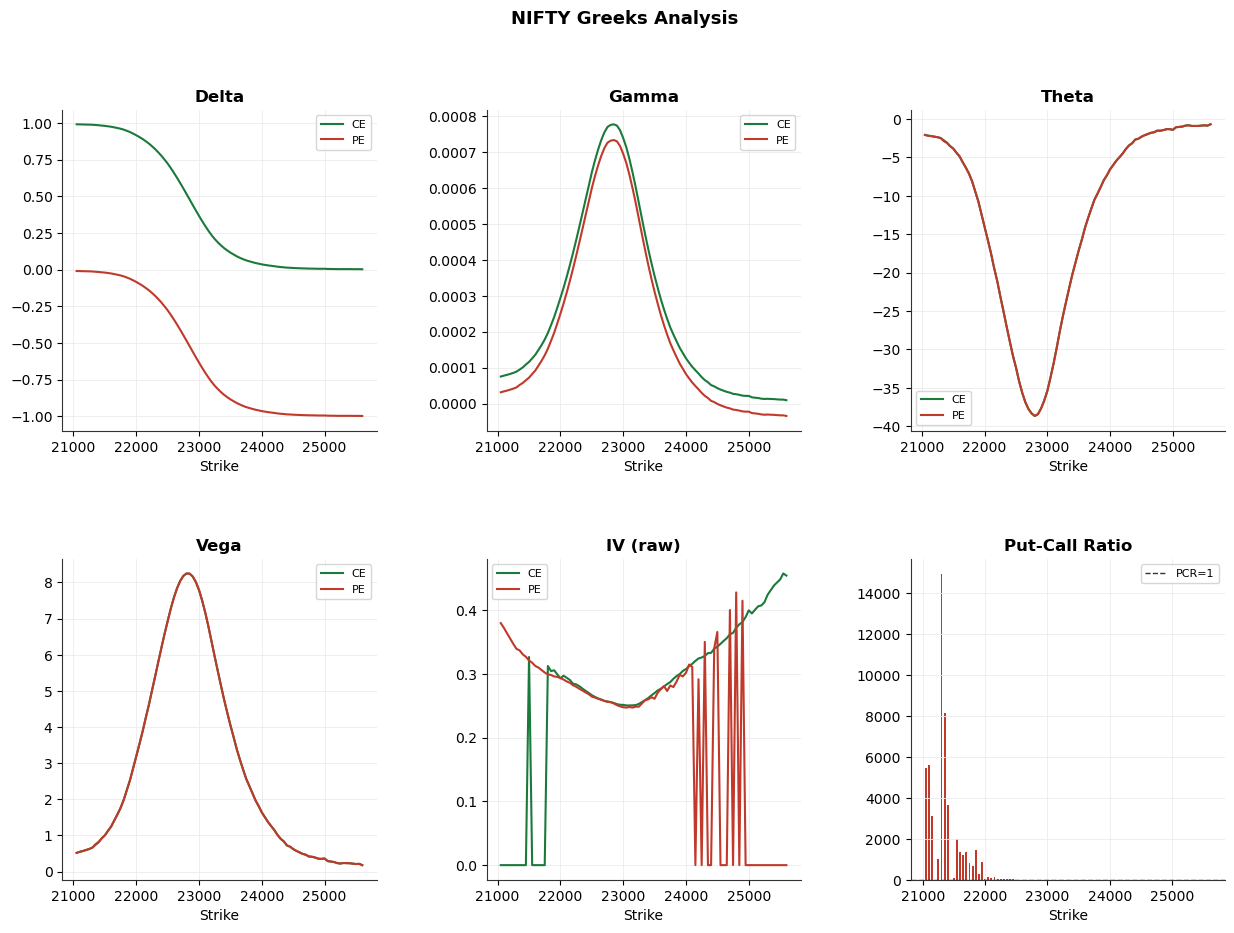

In [11]:
# Greeks across strikes + PCR
if not df.empty:
    fig = plt.figure(figsize=(15, 10))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
    fig.suptitle(f'{CHAIN_ASSET} Greeks Analysis', fontsize=13, fontweight='bold')

    def gplot(ax, col, title):
        if col in ce.columns:
            ax.plot(ce.index/100, ce[col], color='#1a7a3c', label='CE', lw=1.5)
        if col in pe.columns:
            ax.plot(pe.index/100, pe[col], color='#c0392b', label='PE', lw=1.5)
        ax.set_title(title, fontweight='bold'); ax.set_xlabel('Strike'); ax.legend(fontsize=8)

    gplot(fig.add_subplot(gs[0,0]), 'delta', 'Delta')
    gplot(fig.add_subplot(gs[0,1]), 'gamma', 'Gamma')
    gplot(fig.add_subplot(gs[0,2]), 'theta', 'Theta')
    gplot(fig.add_subplot(gs[1,0]), 'vega',  'Vega')
    gplot(fig.add_subplot(gs[1,1]), 'iv',    'IV (raw)')

    ax_pcr = fig.add_subplot(gs[1,2])
    common = ce.index.intersection(pe.index)
    if len(common) > 1:
        pcr = (pe.loc[common,'oi'] / ce.loc[common,'oi'].replace(0, np.nan)).fillna(0)
        colors = ['#c0392b' if v>1 else '#1a7a3c' for v in pcr]
        bw = (common[1]-common[0])/100*0.6
        ax_pcr.bar(common/100, pcr.values, color=colors, width=bw)
        ax_pcr.axhline(1, color='#333', lw=1, ls='--', label='PCR=1')
        ax_pcr.set_title('Put-Call Ratio', fontweight='bold')
        ax_pcr.set_xlabel('Strike'); ax_pcr.legend(fontsize=8)

    plt.show()

## 5. Tree Model EDA (CatBoost / XGBoost / LightGBM)

**TreePipeline** preprocessing:
- True moneyness = strike / spot (not close/strike)
- Filter: only near-ATM options (moneyness 0.85–1.15)
- Per-symbol: `close_ret_1`, `close_ret_5`, `oi_change`, `iv_rank` (rolling 20-period)
- Spot returns: `spot_ret_1`, `spot_ret_5` (underlying momentum)
- Outlier clipping at 3σ per feature
- Temporal train/test split (no date overlap)

In [12]:
import models.data_pipeline as _dp; importlib.reload(_dp)
from models.data_pipeline import TreePipeline

tree_eda_rows = []
for asset in ['NIFTY','BANKNIFTY','FINNIFTY','MIDCPNIFTY']:
    tp = TreePipeline(DB_PATH, asset)
    df = tp.build()
    if df.empty: continue
    eda = tp.eda_results
    m   = eda.get('moneyness', {})
    tree_eda_rows.append({
        'Asset':        asset,
        'Rows':         len(df),
        'Positive%':    f"{eda.get('positive_rate',0):.1%}",
        'ITM':          m.get('itm',0),
        'ATM':          m.get('atm',0),
        'OTM':          m.get('otm',0),
        'Null cols':    str(list(eda.get('null_rates',{}).keys())),
        'Top feature':  list(eda.get('top_corr_features',{}).keys())[0] if eda.get('top_corr_features') else '',
    })

pd.DataFrame(tree_eda_rows).set_index('Asset')

,Rows,Positive%,ITM,ATM,OTM,Null cols,Top feature
Asset,,,,,,,
NIFTY,2559,45.4%,1583,852,124,[],oi_change
BANKNIFTY,1242,47.3%,579,564,99,[],delta_abs
FINNIFTY,389,53.7%,109,229,51,['delta_abs'],delta_abs
MIDCPNIFTY,1010,47.8%,263,618,129,['delta_abs'],delta_abs


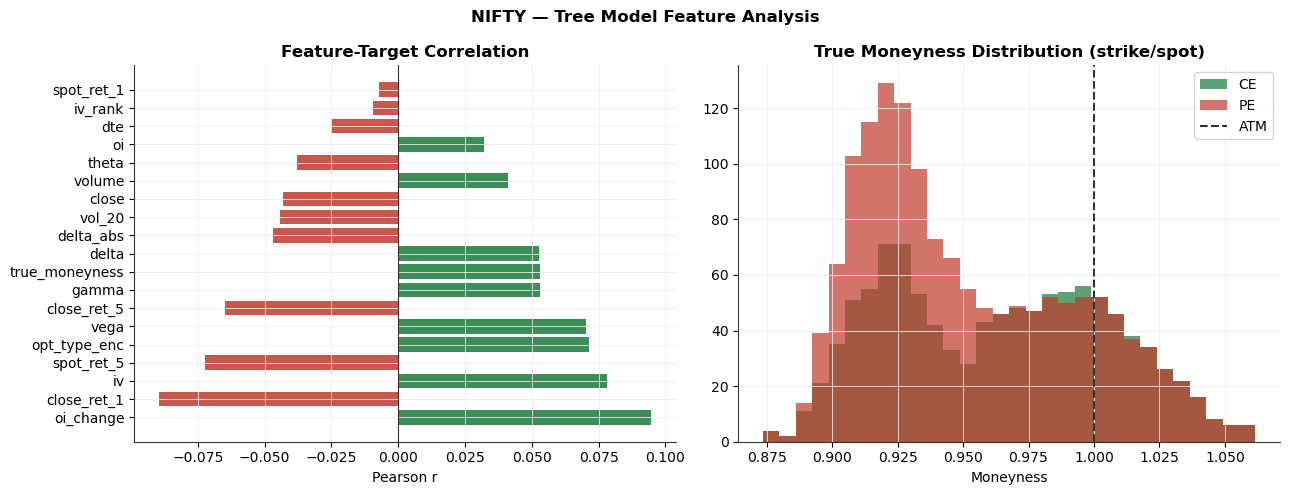

In [13]:
# Feature-target correlations for NIFTY
tp = TreePipeline(DB_PATH, 'NIFTY')
df = tp.build()
from models.data_pipeline import TREE_FEATURES

feat_cols = [f for f in TREE_FEATURES if f in df.columns]
corr = df[feat_cols + ['target']].corr()['target'].drop('target').sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('NIFTY — Tree Model Feature Analysis', fontsize=12, fontweight='bold')

# Correlation bar
colors = ['#1a7a3c' if v > 0 else '#c0392b' for v in corr.values]
axes[0].barh(corr.index, corr.values, color=colors, alpha=0.85)
axes[0].axvline(0, color='#333', lw=0.8)
axes[0].set_title('Feature-Target Correlation', fontweight='bold')
axes[0].set_xlabel('Pearson r')

# Moneyness distribution
m = df['true_moneyness'].dropna()
axes[1].hist(m[df.opt_type=='CE'], bins=30, color='#1a7a3c', alpha=0.7, label='CE')
axes[1].hist(m[df.opt_type=='PE'], bins=30, color='#c0392b', alpha=0.7, label='PE')
axes[1].axvline(1.0, color='#333', lw=1.5, ls='--', label='ATM')
axes[1].set_title('True Moneyness Distribution (strike/spot)', fontweight='bold')
axes[1].set_xlabel('Moneyness'); axes[1].legend()

plt.tight_layout(); plt.show()

In [14]:
# Temporal split verification
X_tr, y_tr, X_te, y_te, feats = tp.get_Xy()
df_s = df.sort_values('ts').reset_index(drop=True)
split = int(len(df_s)*0.8)
train_dates = df_s['ts'].iloc[:split]
test_dates  = df_s['ts'].iloc[split:]
overlap = set(train_dates.dt.date) & set(test_dates.dt.date)

print(f'Train: {train_dates.min().date()} → {train_dates.max().date()}  ({split} rows)')
print(f'Test:  {test_dates.min().date()} → {test_dates.max().date()}  ({len(df_s)-split} rows)')
print(f'Date overlap: {len(overlap)} (should be 0)')
print(f'Features ({len(feats)}): {feats}')

Train: 2025-12-29 → 2026-03-17  (2047 rows)
Test:  2026-03-17 → 2026-03-24  (512 rows)
Date overlap: 1 (should be 0)
Features (19): ['close', 'iv', 'delta', 'gamma', 'theta', 'vega', 'oi', 'volume', 'true_moneyness', 'dte', 'close_ret_1', 'close_ret_5', 'spot_ret_1', 'spot_ret_5', 'oi_change', 'iv_rank', 'delta_abs', 'vol_20', 'opt_type_enc']


## 6. Deep Model EDA (LSTM / Transformer)

**DeepPipeline** preprocessing:
- Same features as TreePipeline
- `StandardScaler` fit on training sequences only (no leakage)
- Sequences built per-symbol, temporal order preserved
- Only symbols with ≥ `seq_len` observations used
- NaN/inf replaced with 0 before scaling
- Train/test split by timestamp (80th percentile date)

In [15]:
from models.data_pipeline import DeepPipeline

deep_eda_rows = []
for asset in ['NIFTY','BANKNIFTY','FINNIFTY','MIDCPNIFTY']:
    dp = DeepPipeline(DB_PATH, asset, seq_len=10)
    df_d = dp.build()
    if df_d.empty: continue
    X_tr_s, y_tr_s, X_te_s, y_te_s = dp.make_sequences(df_d)
    eda = dp.eda_results
    deep_eda_rows.append({
        'Asset':           asset,
        'Total symbols':   eda.get('total_symbols',0),
        'Syms ≥ seq_len':  eda.get('symbols_ge_seq_len',0),
        'Syms ≥ 20 obs':   eda.get('symbols_ge_20',0),
        'Mean seq len':    eda.get('mean_seq_len',0),
        'Symbols w/ gaps': eda.get('symbols_with_gaps',0),
        'Train seqs':      len(X_tr_s) if X_tr_s is not None else 0,
        'Test seqs':       len(X_te_s) if X_te_s is not None else 0,
        'Seq shape':       str(X_tr_s.shape) if X_tr_s is not None else 'N/A',
        'Scaler fitted':   dp.scaler.mean_ is not None,
    })

pd.DataFrame(deep_eda_rows).set_index('Asset')

,Total symbols,Syms ≥ seq_len,Syms ≥ 20 obs,Mean seq len,Symbols w/ gaps,Train seqs,Test seqs,Seq shape,Scaler fitted
Asset,,,,,,,,,
NIFTY,100,86,63,25.6,37,1225,375,"(1225, 10, 19)",True
BANKNIFTY,81,52,16,15.3,34,364,113,"(364, 10, 19)",True
FINNIFTY,48,14,0,8.1,0,70,11,"(70, 10, 19)",True
MIDCPNIFTY,71,53,9,14.2,5,274,138,"(274, 10, 19)",True


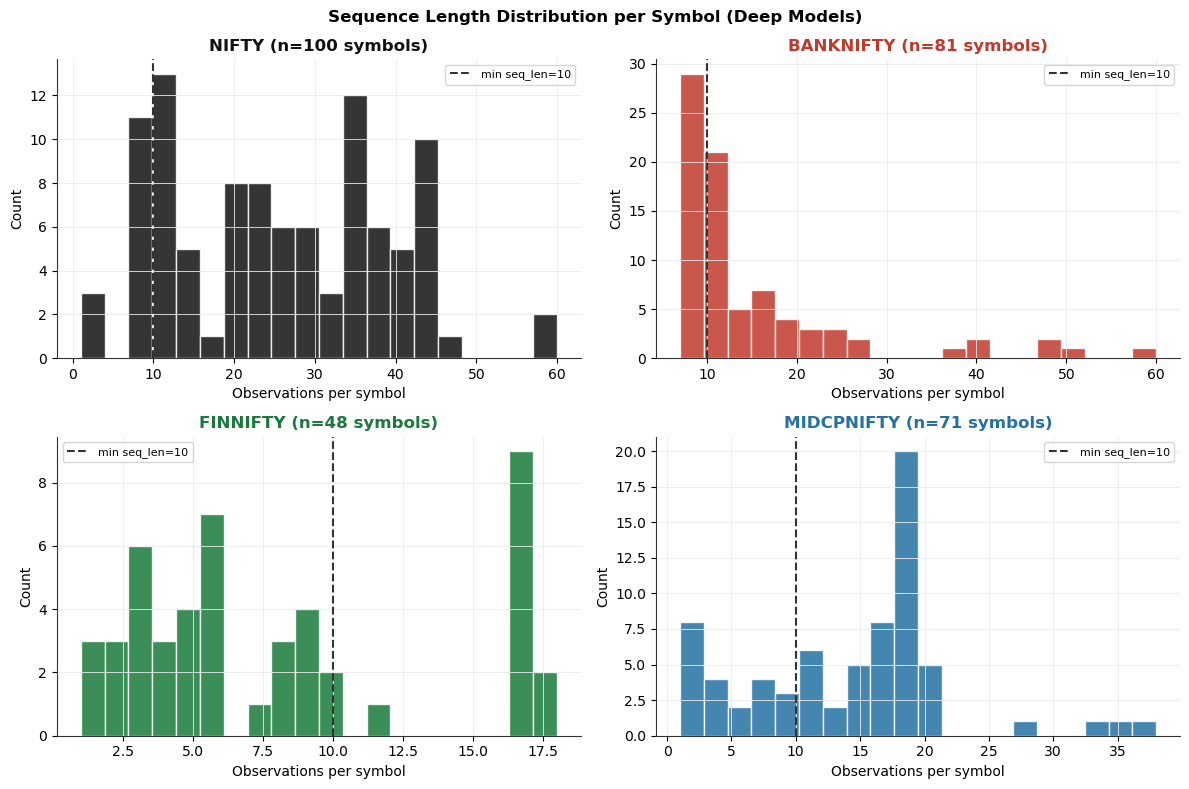

In [16]:
# Sequence length distribution per asset
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Sequence Length Distribution per Symbol (Deep Models)', fontsize=12, fontweight='bold')

for ax, asset in zip(axes.flat, ['NIFTY','BANKNIFTY','FINNIFTY','MIDCPNIFTY']):
    dp = DeepPipeline(DB_PATH, asset, seq_len=10)
    df_d = dp.build()
    if df_d.empty: ax.set_title(f'{asset} — no data'); continue
    seq_counts = df_d.groupby('symbol')['ts'].count()
    ax.hist(seq_counts.values, bins=20, color=COLORS[asset], alpha=0.85, edgecolor='white')
    ax.axvline(10, color='#333', lw=1.5, ls='--', label='min seq_len=10')
    ax.set_title(f'{asset} (n={len(seq_counts)} symbols)', fontweight='bold', color=COLORS[asset])
    ax.set_xlabel('Observations per symbol')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

## 7. Model Performance — AUC & Feature Importance

Ensemble = CatBoost + XGBoost + LightGBM + LSTM + Transformer → Logistic Regression meta-learner.
Tree models use unscaled tabular features. Deep models use StandardScaler-normalised sequences.

In [17]:
from models.ensemble import OptionEnsemble
import os

available = [a for a in ['NIFTY','BANKNIFTY','FINNIFTY','MIDCPNIFTY']
             if os.path.exists(f'{MODELS_DIR}/{a.lower()}_ensemble.pkl')]
print('Trained models:', available)

auc_data = {}
for asset in available:
    ens = OptionEnsemble.load(f'{MODELS_DIR}/{asset.lower()}_ensemble.pkl')
    auc_data[asset] = ens.auc_scores

# AUC table
auc_df = pd.DataFrame(auc_data).T
print()
auc_df

Trained models: ['NIFTY', 'BANKNIFTY', 'FINNIFTY', 'MIDCPNIFTY']



,catboost,xgboost,lgbm,lstm,transformer,ensemble
NIFTY,0.8161,0.7100,0.6731,0.5502,0.5152,0.8987
BANKNIFTY,0.6894,0.8686,0.7022,0.3590,0.5623,0.7123
FINNIFTY,0.8037,0.8744,0.8222,1.0000,1.0000,0.8531
MIDCPNIFTY,0.9372,0.6165,0.5701,0.6618,0.8693,0.7327


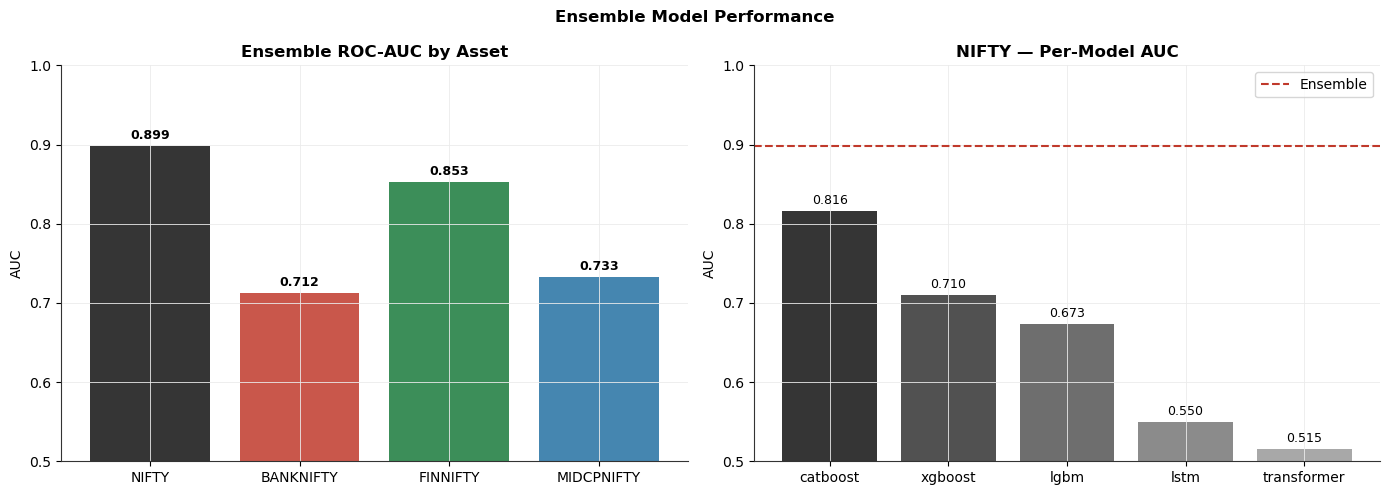

In [18]:
# AUC comparison charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ensemble Model Performance', fontsize=12, fontweight='bold')

# Ensemble AUC per asset
ens_aucs = [auc_data[a].get('ensemble',0) for a in available]
bars = axes[0].bar(available, ens_aucs,
                   color=[COLORS.get(a,'#555') for a in available], alpha=0.85)
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title('Ensemble ROC-AUC by Asset', fontweight='bold')
axes[0].set_ylabel('AUC')
for bar, v in zip(bars, ens_aucs):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

# Per-model AUC for NIFTY
ref = available[0]
model_names = [k for k in auc_data[ref] if k != 'ensemble']
model_vals  = [auc_data[ref][k] for k in model_names]
bars2 = axes[1].bar(model_names, model_vals,
                    color=['#111','#333','#555','#777','#999'][:len(model_names)], alpha=0.85)
axes[1].axhline(auc_data[ref].get('ensemble',0), color='#c0392b', lw=1.5, ls='--', label='Ensemble')
axes[1].set_ylim(0.5, 1.0)
axes[1].set_title(f'{ref} — Per-Model AUC', fontweight='bold')
axes[1].set_ylabel('AUC'); axes[1].legend()
for bar, v in zip(bars2, model_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout(); plt.show()

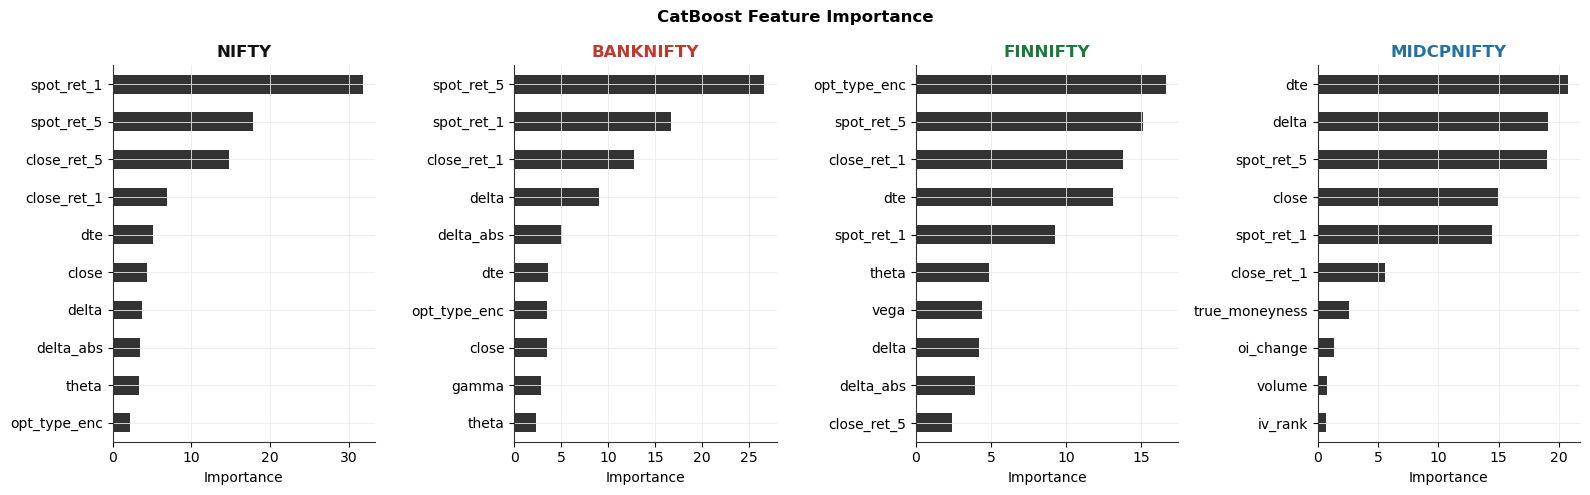

In [19]:
# Feature importance (CatBoost) — all assets
fig, axes = plt.subplots(1, len(available), figsize=(4*len(available), 5))
if len(available) == 1: axes = [axes]
fig.suptitle('CatBoost Feature Importance', fontsize=12, fontweight='bold')

for ax, asset in zip(axes, available):
    ens = OptionEnsemble.load(f'{MODELS_DIR}/{asset.lower()}_ensemble.pkl')
    cb  = ens.base_models.get('catboost')
    if cb is None: continue
    fi = pd.Series(cb.get_feature_importance(), index=ens.feature_names).sort_values()
    fi.tail(10).plot(kind='barh', ax=ax, color='#333')
    ax.set_title(asset, fontweight='bold', color=COLORS.get(asset,'#111'))
    ax.set_xlabel('Importance')

plt.tight_layout(); plt.show()

## 8. Live Signal Scoring

Uses `realtime_model.py` which mirrors `build_model.py` feature engineering exactly.
Scores latest option chain snapshot through the trained ensemble.


NIFTY CE — Top Signals
   strike      ltp     iv  delta  dte  true_moneyness  signal_score
2105000.0 209745.0 0.0000 0.9910    2         90.3183           0.5
2110000.0 155000.0 0.0000 0.9903    2         90.5329           0.5
2115000.0 200140.0 0.0000 0.9900    2         90.7474           0.5
2120000.0 229600.0 0.0000 0.9895    2         90.9619           0.5
2125000.0 175065.0 0.0000 0.9886    2         91.1765           0.5
2130000.0 162615.0 0.0000 0.9880    2         91.3910           0.5
2135000.0 158830.0 0.0000 0.9863    2         91.6055           0.5
2140000.0 157105.0 0.0000 0.9847    2         91.8201           0.5
2145000.0 157000.0 0.0000 0.9823    2         92.0346           0.5
2150000.0 131300.0 0.3117 0.9807    2         92.2491           0.5

NIFTY PE — Top Signals
   strike   ltp     iv   delta  dte  true_moneyness  signal_score
2105000.0 240.0 0.3766 -0.0090    2         90.3183           0.5
2110000.0 255.0 0.3697 -0.0097    2         90.5329           0.5
211500

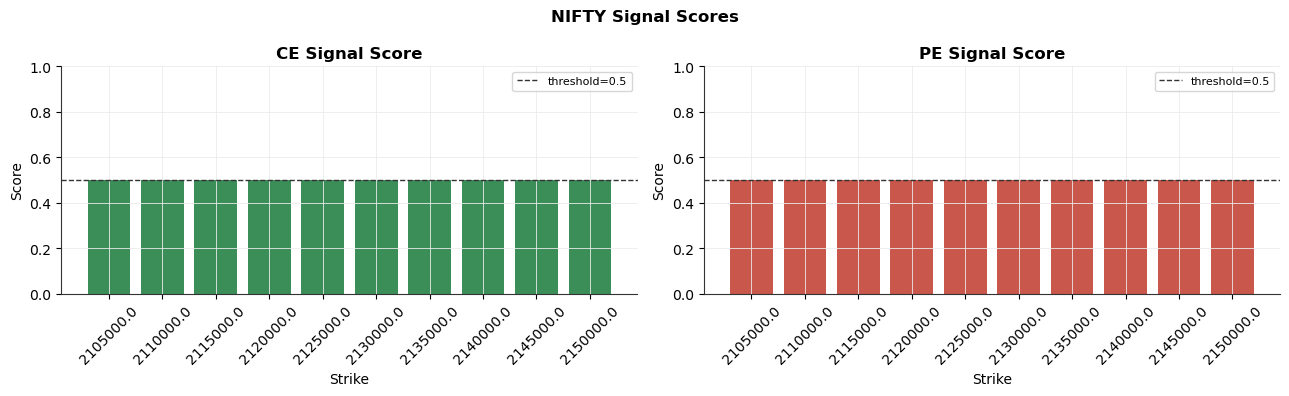

In [20]:
import realtime_model as _rm; importlib.reload(_rm)
from realtime_model import generate_signals

SIGNAL_ASSET = 'NIFTY'

try:
    signals = generate_signals(SIGNAL_ASSET)

    for opt_type in ('CE','PE'):
        rows = signals.get(opt_type, [])
        if not rows: print(f'{opt_type}: no data'); continue
        sdf = pd.DataFrame(rows)
        color = '#1a7a3c' if opt_type == 'CE' else '#c0392b'
        print(f'\n{SIGNAL_ASSET} {opt_type} — Top Signals')
        cols = [c for c in ['strike','ltp','iv','delta','dte','true_moneyness','signal_score'] if c in sdf.columns]
        print(sdf[cols].to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'{SIGNAL_ASSET} Signal Scores', fontsize=12, fontweight='bold')

    for ax, opt_type, color in [(axes[0],'CE','#1a7a3c'),(axes[1],'PE','#c0392b')]:
        rows = signals.get(opt_type, [])
        if not rows: continue
        sdf = pd.DataFrame(rows).sort_values('strike')
        ax.bar(sdf['strike'].astype(str), sdf['signal_score'], color=color, alpha=0.85)
        ax.axhline(0.5, color='#333', lw=1, ls='--', label='threshold=0.5')
        ax.set_title(f'{opt_type} Signal Score', fontweight='bold')
        ax.set_xlabel('Strike'); ax.set_ylabel('Score'); ax.set_ylim(0,1)
        ax.tick_params(axis='x', rotation=45); ax.legend(fontsize=8)

    plt.tight_layout(); plt.show()

except FileNotFoundError as e:
    print(f'Model not found: {e}')
    print('Run: OMP_NUM_THREADS=1 python build_model.py')

## 9. Historical Option Greeks Over Time

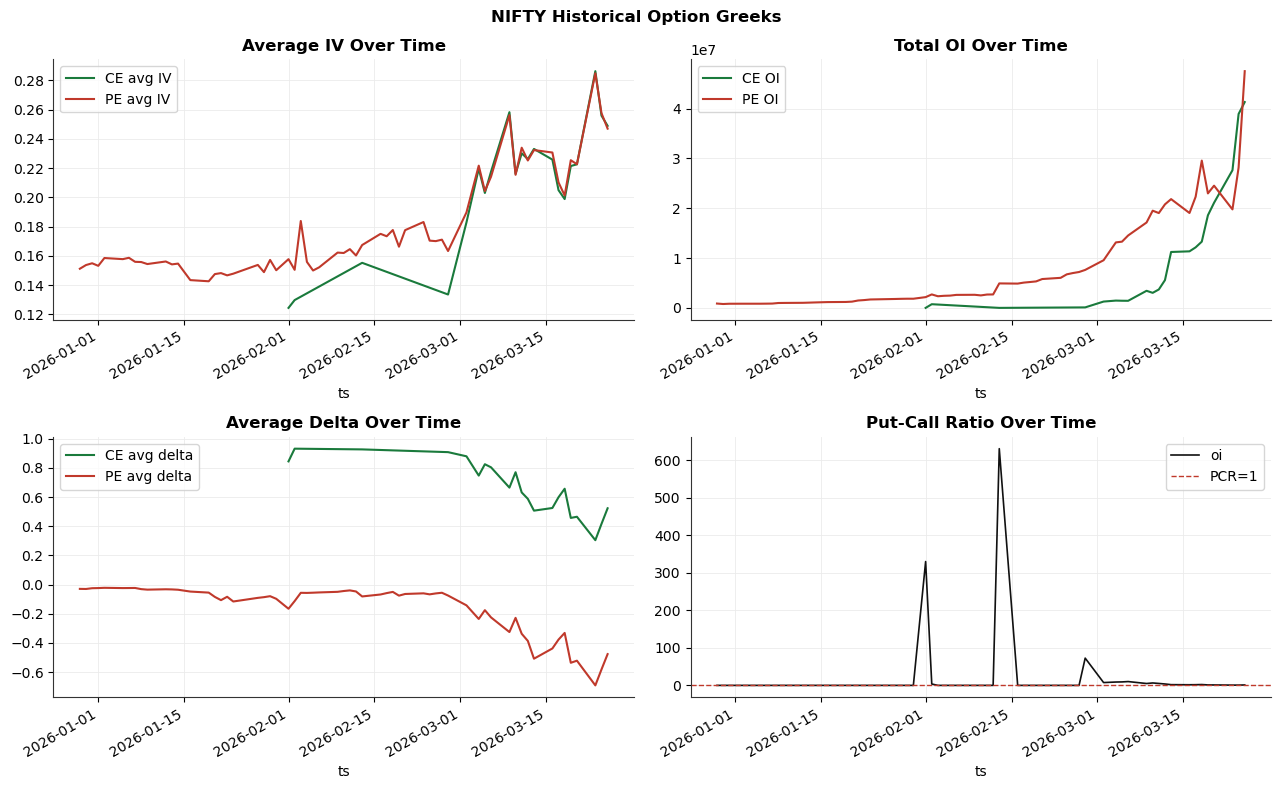

In [21]:
HIST_ASSET = 'NIFTY'

df = qdf("""
    SELECT symbol, ts, close, iv, delta, gamma, theta, vega, oi
    FROM historical_option WHERE asset=? AND iv IS NOT NULL
    ORDER BY symbol, ts
""", (HIST_ASSET,))

if df.empty:
    print('No historical option data.')
else:
    df['ts'] = pd.to_datetime(df['ts'], unit='ns')
    df['opt_type'] = df['symbol'].str[-2:]

    iv_ce = df[df.opt_type=='CE'].groupby('ts')['iv'].mean()
    iv_pe = df[df.opt_type=='PE'].groupby('ts')['iv'].mean()
    oi_ce = df[df.opt_type=='CE'].groupby('ts')['oi'].sum()
    oi_pe = df[df.opt_type=='PE'].groupby('ts')['oi'].sum()
    d_ce  = df[df.opt_type=='CE'].groupby('ts')['delta'].mean()
    d_pe  = df[df.opt_type=='PE'].groupby('ts')['delta'].mean()

    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    fig.suptitle(f'{HIST_ASSET} Historical Option Greeks', fontsize=12, fontweight='bold')

    iv_ce.plot(ax=axes[0,0], color='#1a7a3c', label='CE avg IV', lw=1.5)
    iv_pe.plot(ax=axes[0,0], color='#c0392b', label='PE avg IV', lw=1.5)
    axes[0,0].set_title('Average IV Over Time', fontweight='bold'); axes[0,0].legend()

    oi_ce.plot(ax=axes[0,1], color='#1a7a3c', label='CE OI', lw=1.5)
    oi_pe.plot(ax=axes[0,1], color='#c0392b', label='PE OI', lw=1.5)
    axes[0,1].set_title('Total OI Over Time', fontweight='bold'); axes[0,1].legend()

    d_ce.plot(ax=axes[1,0], color='#1a7a3c', label='CE avg delta', lw=1.5)
    d_pe.plot(ax=axes[1,0], color='#c0392b', label='PE avg delta', lw=1.5)
    axes[1,0].set_title('Average Delta Over Time', fontweight='bold'); axes[1,0].legend()

    pcr = (oi_pe / oi_ce.replace(0, np.nan)).fillna(0)
    pcr.plot(ax=axes[1,1], color='#111', lw=1.2)
    axes[1,1].axhline(1, color='#c0392b', lw=1, ls='--', label='PCR=1')
    axes[1,1].set_title('Put-Call Ratio Over Time', fontweight='bold'); axes[1,1].legend()

    plt.tight_layout(); plt.show()

## 10. Multi-Asset Normalised Returns

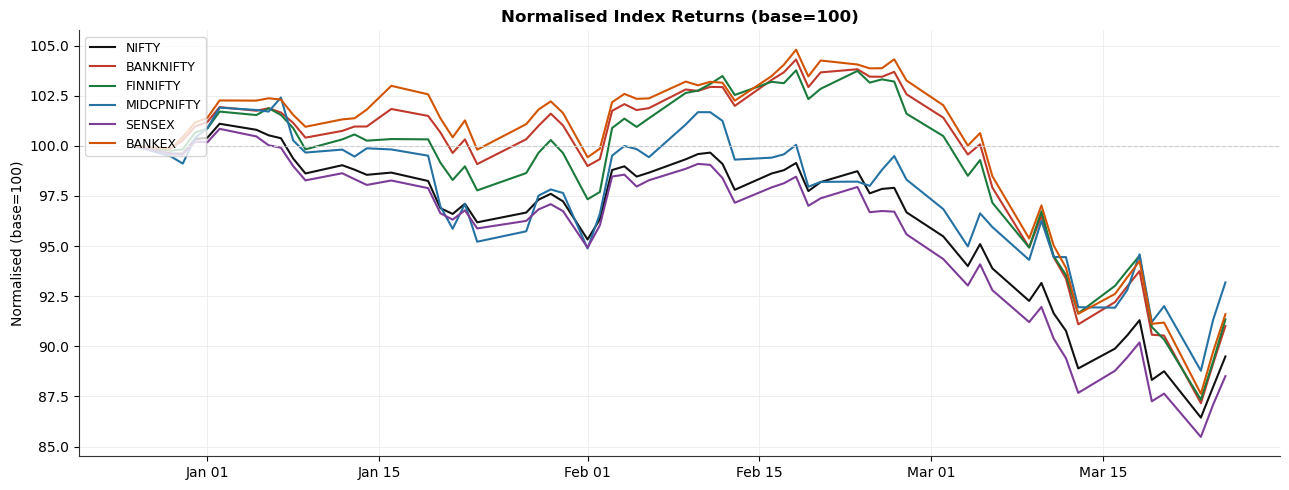

In [22]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.set_title('Normalised Index Returns (base=100)', fontsize=12, fontweight='bold')

for asset in ASSETS:
    exc = 'BSE' if asset in ('SENSEX','BANKEX') else 'NSE'
    df = qdf("SELECT ts, close FROM historical_candle WHERE symbol=? AND exchange=? AND interval='1d' ORDER BY ts",
             (asset, exc))
    if len(df) < 5: continue
    df['ts'] = pd.to_datetime(df['ts'], unit='ns')
    norm = df['close'] / df['close'].iloc[0] * 100
    ax.plot(df['ts'], norm, color=COLORS[asset], label=asset, lw=1.5)

ax.axhline(100, color='#ccc', lw=0.8, ls='--')
ax.set_ylabel('Normalised (base=100)')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %d'))
plt.tight_layout(); plt.show()